<a href="https://colab.research.google.com/github/carlosvasquez3/M.Sc.-in-Data-Science/blob/main/Estad%C3%ADstica/TRM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GRUPO 7**

Camilo Andres Acosta Perez

Luis Miguel Restrepo Giraldo

Carlos Enrique Vásquez Ortiz

**INTRODUCCIÓN**

La base de datos que se descargó corresponde a la TRM COP/USD del Banco de la República, la cual abarca el periodo desde el 27 de noviembre de 1991 hasta la fecha de descarga, es decir, el 27 de marzo de 2026. En total, contiene 12.540 registros con periodicidad diaria.

La principal motivación para estudiar la TRM es analizar cómo sus fluctuaciones pueden afectar a los colombianos, desde quienes administran empresas que importan mercancías hasta los exportadores, como los productores de flores en temporadas como febrero (San Valentín).

Se entiende que cuando los importadores compran bienes en el exterior, les favorece que la TRM sea baja, ya que necesitan menos pesos para adquirir los productos. En contraste, para los exportadores de flores, les conviene que la TRM sea alta, pues por cada venta reciben más pesos.

Otro ejemplo son las remesas enviadas desde el exterior hacia Colombia: para quienes las reciben en el país es más favorable una TRM alta, ya que obtienen más dinero en pesos. Por el contrario, cuando se realizan compras en el exterior, como en Amazon, es más conveniente una TRM baja, porque se requieren menos pesos para pagar los productos.

A partir del análisis de la serie de tiempo de la TRM, se busca comprender cómo las políticas monetarias y las circunstancias económicas de cada época afectan este importante indicador.


**Exploratory Data Analysis**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Se carga la base de datos correspondiente a la TRM del Banco de la República, para su posterior análisis.

In [3]:
trm = pd.read_excel("https://raw.githubusercontent.com/carlosvasquez3/M.Sc.-in-Data-Science/main/Estad%C3%ADstica/Tasa%20de%20cambio%20del%20peso%20colombiano%20(19).xlsx")

In [4]:
trm.head()

,Fecha,Tasa Representativa del Mercado (TRM)
0,yyyy/mm/dd,COP/USD
1,1991/11/27,693.32
2,1991/11/28,693.99
3,1991/11/29,694.7
4,1991/11/30,694.7


In [ ]:
trm = trm.drop(index=0)

In [6]:
trm.head()

,Fecha,Tasa Representativa del Mercado (TRM)
1,1991/11/27,693.32
2,1991/11/28,693.99
3,1991/11/29,694.7
4,1991/11/30,694.7
5,1991/12/01,643.42


In [27]:
trm.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12540 entries, 1991-11-27 to 2026-03-27
Data columns (total 1 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Tasa Representativa del Mercado (TRM)  12540 non-null  object
dtypes: object(1)
memory usage: 195.9+ KB


**2.1 Limpieza y preprocesamiento**

Se realiza la limpieza de la base de datos eliminando filas no válidas y transformando los tipos de datos necesarios para el análisis.

In [8]:
trm['Fecha'] = pd.to_datetime(trm['Fecha'], errors='coerce')
trm = trm.dropna(subset=['Fecha'])

In [9]:
trm

,Fecha,Tasa Representativa del Mercado (TRM)
1,1991-11-27,693.32
2,1991-11-28,693.99
3,1991-11-29,694.7
4,1991-11-30,694.7
5,1991-12-01,643.42
...,...,...
12536,2026-03-23,3704.87
12537,2026-03-24,3704.87
12538,2026-03-25,3700.67
12539,2026-03-26,3688.46


In [10]:
trm['Fecha'] = pd.to_datetime(trm['Fecha'], format='%Y-%m-%d')

Se eliminan filas que no corresponden a observaciones válidas y se convierten las variables al formato adecuado.

Finalmente, los datos se ordenan cronológicamente para garantizar la coherencia de la serie de tiempo.

In [11]:
trm = trm.sort_values("Fecha")
trm = trm.set_index("Fecha")

**2.2 Variables y naturaleza de la serie**

- Variable temporal: Fecha
- Variable de interés: Tasa Representativa del Mercado (TRM)
- Tipo de variable: cuantitativa continua
- Tipo de serie: univariada
- Frecuencia: diaria

Esto indica que cada observación depende del tiempo, por lo que se trata de una serie de tiempo.

**2.3 Visualización inicial**



In [25]:
fig = px.line(trm,x =trm.index ,y='Tasa Representativa del Mercado (TRM)', title='Evolución de la TRM en Colombia')
fig.update_layout(xaxis_title='Fecha', yaxis_title='Tasa Representativa del Mercado (COP/USD)')
fig.show()

A partir de la gráfica se pueden identificar cambios en la tendencia general, periodos de alta volatilidad y posibles cambios bruscos asociados a eventos externos.

**2.4 Estadísticas descriptivas**

In [31]:
serie = trm["Tasa Representativa del Mercado (TRM)"]
serie.describe()

,Tasa Representativa del Mercado (TRM)
count,12540.00
unique,8050.00
top,1907.06
freq,9.00


Inicialmente, la variable TRM fue interpretada incorrectamente, mostrando estadísticas propias de variables categóricas.

Por esta razón, se realizó una conversión explícita a tipo numérico para obtener estadísticas descriptivas adecuadas.

In [32]:
serie = pd.to_numeric(trm["Tasa Representativa del Mercado (TRM)"], errors="coerce")
serie.describe()

,Tasa Representativa del Mercado (TRM)
count,12540.000000
mean,2368.461335
std,1034.201023
min,620.620000
25%,1785.250000
50%,2272.035000
75%,2999.712500
max,5061.210000


Las estadísticas descriptivas permiten observar el comportamiento general de la TRM.

La media representa el valor promedio del dólar en el periodo analizado, mientras que la desviación estándar refleja la variabilidad de la serie.

El rango entre el valor mínimo y máximo evidencia los cambios que ha experimentado la TRM a lo largo del tiempo.

**2.5 Detección de valores atípicos**

Se utiliza un boxplot para identificar posibles observaciones extremas en la serie.

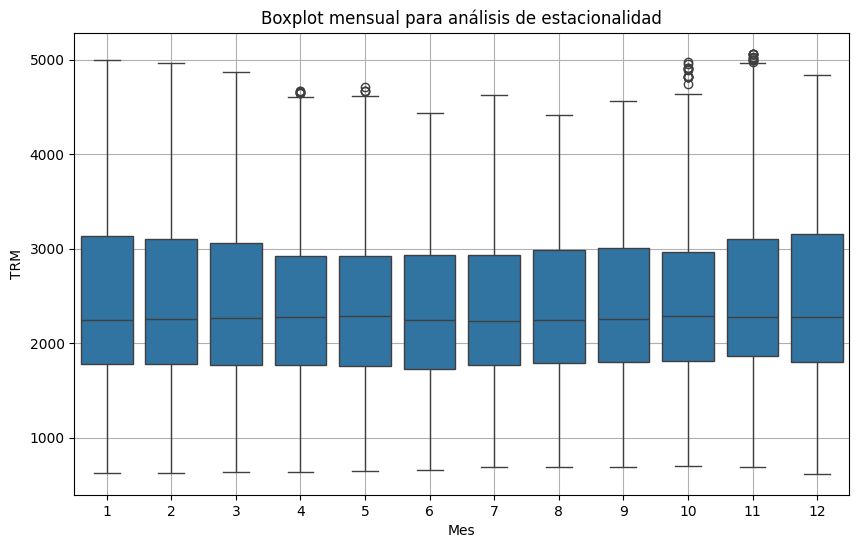

In [34]:
trm["month"] = trm.index.month

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x="month", y="Tasa Representativa del Mercado (TRM)", data=trm)

plt.title("Boxplot mensual para análisis de estacionalidad")
plt.xlabel("Mes")
plt.ylabel("TRM")
plt.grid(True)

plt.show()

Se identifican valores atípicos en la serie, evidenciados por puntos fuera del rango del boxplot.

Estos representan cambios bruscos en la TRM y sugieren la presencia de alta volatilidad en ciertos periodos.

**Análisis de estacionalidad**

El boxplot por mes permite observar la distribución de la TRM en cada periodo del año, considerando todos los años disponibles.

Cada caja representa la variabilidad del valor del dólar en ese mes específico, mostrando la mediana, dispersión y posibles valores atípicos.

A partir de la gráfica se observa que las medianas son relativamente similares entre los meses, lo que sugiere que no existe una estacionalidad fuerte en la serie. Sin embargo, se identifican valores atípicos especialmente en meses como octubre y noviembre, donde se presentan picos altos de la TRM, cercanos a los valores máximos de la serie.

Esto indica que, aunque el comportamiento del dólar no sigue un patrón estacional claro, sí presenta episodios de alta volatilidad asociados a eventos económicos específicos.

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

trm_comps_add = seasonal_decompose(trm['Tasa Representativa del Mercado (TRM)'], model='additive',period= 365)

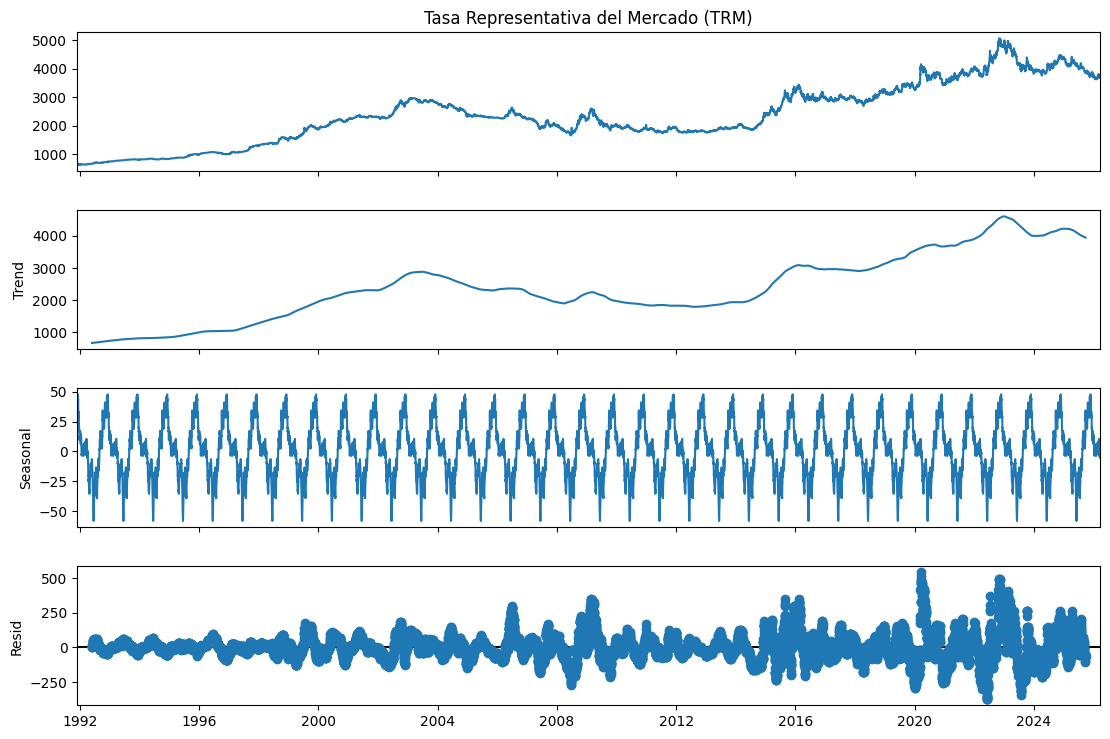

In [15]:
fig = trm_comps_add.plot()
fig.set_size_inches((12,8))

In [16]:
print('Promedio de los residuales (descomposición aditiva):', trm_comps_add.resid.mean())

Promedio de los residuales (descomposición aditiva): 1.233049016965317


In [17]:
trm_comps_mult = seasonal_decompose(trm['Tasa Representativa del Mercado (TRM)'], model='multiplicative',period= 365)


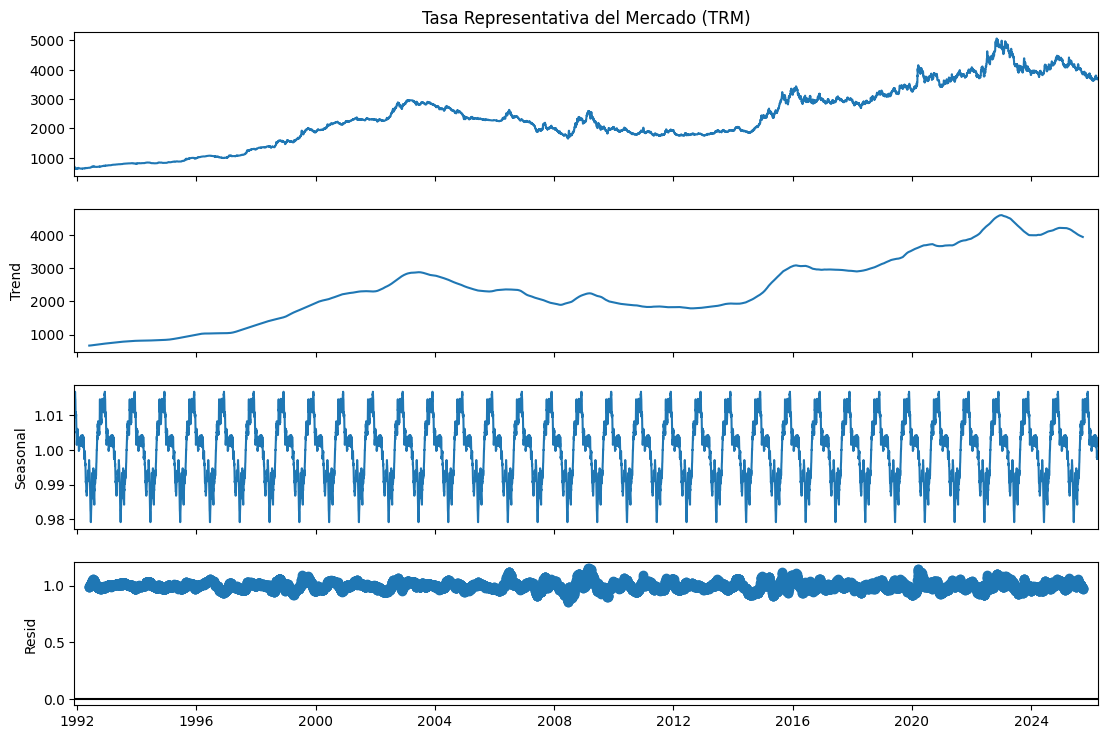

In [18]:
fig = trm_comps_mult.plot()
fig.set_size_inches((12,8))

In [19]:
print('Promedio de los residuales (descomposición multiplicativa):', trm_comps_mult.resid.mean())

Promedio de los residuales (descomposición multiplicativa): 0.9996869389881624


In [20]:
from statsmodels.tsa.seasonal import STL

trm_stl = STL(trm['Tasa Representativa del Mercado (TRM)'], period=365).fit()


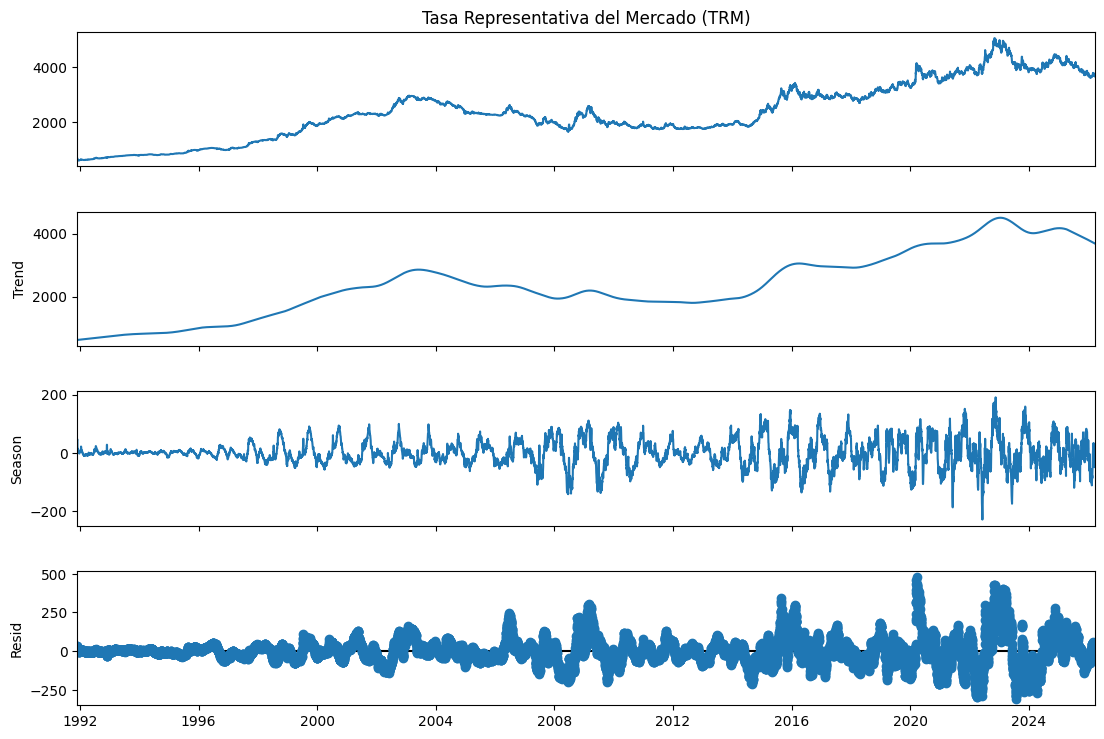

In [21]:
fig = trm_stl.plot()
fig.set_size_inches((12,8))

In [22]:
print('Promedio de los residuales (descomposición STL):', trm_stl.resid.mean())

Promedio de los residuales (descomposición STL): 1.157982347805179
